## Librerias

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga datos clean

In [ ]:
df_operaciones = pd.read_csv('../../data/data_cleaning/operaciones_11-03-2026.csv', parse_dates=['insert_date'])

availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

## Análisis / visualizaciones
Quina és la disponibilitat mitjana dels allotjaments
turístics en els diferents terminis (30, 60, 90 i 365 dies) a cada ciutat?

In [ ]:

disponibilidad_ciudad = (
    df_operaciones
    .groupby("city")[availability_cols]
    .mean()
    .round(1)
    .reset_index()
)

disponibilidad_ciudad

,city,availability_30,availability_60,availability_90,availability_365
0,Barcelona,11.1,25.5,42.3,181.4
1,Girona,14.4,31.0,48.1,194.1
2,Madrid,10.4,24.1,39.9,163.6
3,Malaga,12.2,28.6,47.4,203.1
4,Mallorca,13.1,28.2,44.5,208.5
5,Menorca,14.6,30.2,47.1,197.6
6,Sevilla,13.8,30.3,49.5,199.1
7,Valencia,13.4,29.5,47.5,183.3


In [27]:
df_operaciones["avail_ratio_30"] = df_operaciones["availability_30"] / 30
df_operaciones["avail_ratio_60"] = df_operaciones["availability_60"] / 60
df_operaciones["avail_ratio_90"] = df_operaciones["availability_90"] / 90
df_operaciones["avail_ratio_365"] = df_operaciones["availability_365"] / 365

avail_ratio_cols = [
    "avail_ratio_30",
    "avail_ratio_60",
    "avail_ratio_90",
    "avail_ratio_365"
]

disponibilidad_ciudad = (
    df_operaciones
    .groupby("city")[avail_ratio_cols]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

disponibilidad_ciudad

,city,avail_ratio_30,avail_ratio_60,avail_ratio_90,avail_ratio_365
0,Barcelona,36.8,42.5,47.0,49.7
1,Girona,48.0,51.7,53.4,53.2
2,Madrid,34.6,40.2,44.4,44.8
3,Malaga,40.6,47.7,52.7,55.6
4,Mallorca,43.5,46.9,49.4,57.1
5,Menorca,48.8,50.4,52.4,54.1
6,Sevilla,45.9,50.5,55.0,54.5
7,Valencia,44.8,49.1,52.7,50.2


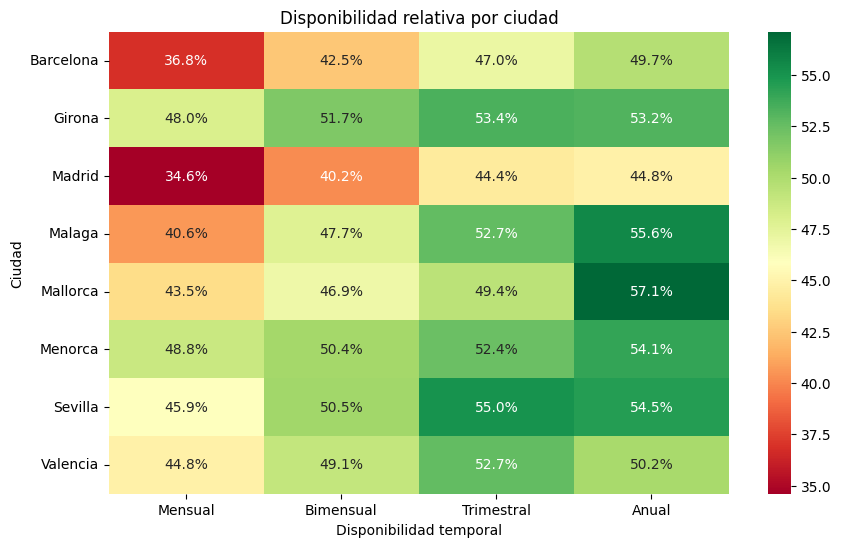

In [36]:
data = disponibilidad_ciudad.set_index("city")
labels = data.round(2).astype(str) + "%"

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    data,
    annot=labels,
    cmap="RdYlGn",
    fmt=""
)

ax.set_title("Disponibilidad relativa por ciudad")
ax.set_ylabel("Ciudad")
ax.set_xlabel("Disponibilidad temporal")
ax.set_xticklabels(["Mensual","Bimensual","Trimestral","Anual"])

plt.show()

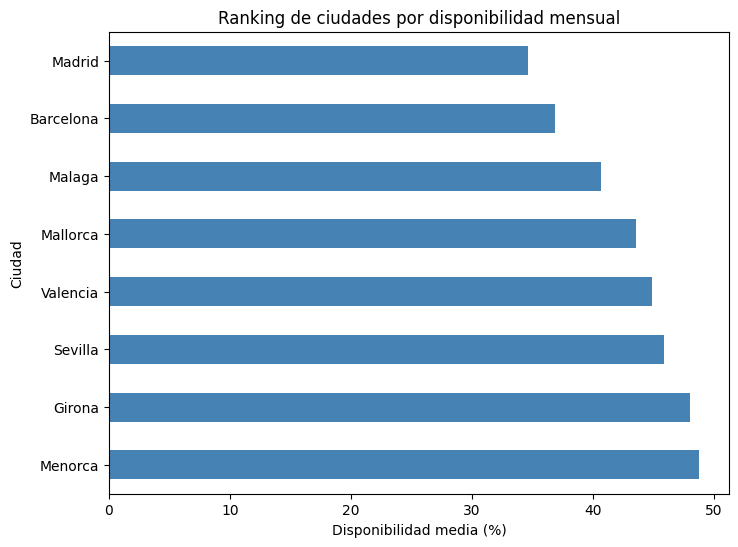

In [41]:
disponibilidad_mensual = (
    df_operaciones
    .groupby("city")["avail_ratio_30"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))

disponibilidad_mensual.plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Disponibilidad media (%)")
plt.ylabel("Ciudad")
plt.title("Ranking de ciudades por disponibilidad mensual")

plt.show()

## Resultados / archivos generados